# Loan Approval Prediction using Machine Learning

## Project Objective

The objective of this project is to build and compare multiple machine learning models capable of predicting whether a loan application will be approved based on applicant information.

---

### Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

### Final Deliverables

- Trained model
- Preprocessing pipeline
- Feature list
- AWS S3 deployment

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score, roc_auc_score,roc_curve,auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

Load the loan application dataset and inspect its basic structure.

In [2]:
df = pd.read_csv("../Data/train_data.csv")

df_original = df.copy() #copy data to a failsafe variable

print("Data shape:", df.shape)
print("\nColumns:", df.columns.tolist())



Data shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


## 3. Initial Data Exploration

Understand the dataset structure, feature types, and summary statistics before preprocessing.

print("=" * 50)
print("First 5 rows of the dataset:")
print("=" * 50)

print(df.head())

print("=" * 50)
print("Dataset information:")
print("=" * 50)
df.info()

print("=" * 50)
print("Statistical summary of numerical columns:")
print("=" * 50)
df.describe()

## 4. Exploratory Data Analysis

Explore important characteristics of the dataset such as target distribution and missing values.

In [4]:
print("=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)
print(df['Loan_Status'].value_counts())

print("Aproval Rate: ", round(df['Loan_Status'].value_counts()['Y'] / len(df) *100 ,2), "%")

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
print(missing[missing>0])

TARGET DISTRIBUTION
Loan_Status
Y    422
N    192
Name: count, dtype: int64
Aproval Rate:  68.73 %
MISSING VALUES
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


## 5. Data Preprocessing

Prepare the data by handling missing values and encoding categorical variables.

In [5]:
#categorical columns with missing values
cat_cols = ['Gender', 'Married', 'Dependents','Self_Employed', 'Credit_History','Loan_Amount_Term'] 

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)

#numerical column with missing values
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "remaining")
    

Missing values after cleaning:
0 remaining


In [6]:
le = LabelEncoder()
#categorical columns to encode
cat_encode = ['Gender', 'Married', 'Dependents','Education', 'Self_Employed','Property_Area', 'Loan_Status']

for col in cat_encode:
    df[col] = le.fit_transform(df[col])
    
print("\nEncoding Completed\nFirst 10 rows: ")

df[['Gender', 'Married', 'Dependents','Education', 'Self_Employed','Property_Area', 'Loan_Status']].head(10)


Encoding Completed
First 10 rows: 


,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,1,0,0,0,0,2,1
1,1,1,1,0,0,0,0
2,1,1,0,0,1,2,1
3,1,1,0,1,0,2,1
4,1,0,0,0,0,2,1
5,1,1,2,0,1,2,1
6,1,1,0,1,0,2,1
7,1,1,3,0,0,1,0
8,1,1,2,0,0,2,1
9,1,1,1,0,0,1,0


## 6. Feature Engineering

Create additional features that may better represent an applicant's financial situation.

In [7]:
# Create total household income by combining applicant and coapplicant income
df['Total_Income']    = df['ApplicantIncome'] + df['CoapplicantIncome']

# Estimate the Equated Monthly Installment (EMI) from the loan amount and repayment term
df['EMI']             = df['LoanAmount'] / df['Loan_Amount_Term'] 

# Estimate the applicant's remaining income after accounting for monthly loan repayments
df['Balance_Income']  = df['Total_Income'] - (df['EMI'] * 1000)

# Apply log transformation to reduce the skewness of loan amounts
df['LoanAmount_log']  = np.log(df['LoanAmount'] + 1)

# Apply log transformation to reduce the skewness of total income
df['Total_Income_log']= np.log(df['Total_Income'] + 1)

## 7. Train-Test Split

Split the data into training and testing sets to evaluate model performance on unseen data.

In [8]:
drop_cols    = ['Loan_ID', 'ApplicantIncome','CoapplicantIncome', 'LoanAmount','Total_Income']
feature_cols = [c for c in df.columns if c not in drop_cols + ['Loan_Status']]

print("\nFinal feature columns:\n")
print(feature_cols, '\n')

X = df[feature_cols]
y = df['Loan_Status']

print(f"Target distribution:\n")

print(y.value_counts()) #count the frequency of unique values

print("\n1 = Approved, 0 = Rejected")

print(f"\nApproval rate: {y.mean()*100:.1f}%\n")

# Preserve class distribution using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print(f"\nTrain approval rate: {y_train.mean()*100:.1f}%")
print(f"Test approval rate:  {y_test.mean()*100:.1f}%")


Final feature columns:

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'EMI', 'Balance_Income', 'LoanAmount_log', 'Total_Income_log'] 

Target distribution:

Loan_Status
1    422
0    192
Name: count, dtype: int64

1 = Approved, 0 = Rejected

Approval rate: 68.7%

Train size: (491, 12)
Test size:  (123, 12)

Train approval rate: 68.6%
Test approval rate:  69.1%


## 8. Model Training

Train three machine learning models for comparison.

In [9]:
# Define the cross-validation strategy for hyperparameter tuning
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42) 

### Logistic Regression

In [10]:
# Feature Scaling
# Standardize numerical features for Logistic Regression.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=feature_cols)
X_test_scaled_df = pd.DataFrame( X_test_scaled,columns=feature_cols)

print("Scaling done!")

Scaling done!


In [16]:
# Define the hyperparameter search space for Logistic Regression
lr_params = {
    'C':        [0.5, 1.0, 2.0, 5.0],
    'penalty':  ['l2'],
    'solver':   ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

# Perform grid search with stratified cross-validation to identify the best model configuration
lr_grid = GridSearchCV(
    LogisticRegression(
        random_state=42,
        class_weight='balanced'
    ),
    lr_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

# Train the grid search and select the best-performing estimator
lr_grid.fit(X_train_scaled_df, y_train)
lr_model = lr_grid.best_estimator_

# Generate predictions and predicted probabilities on the test set
lr_pred = lr_model.predict(X_test_scaled_df)
lr_proba = lr_model.predict_proba( X_test_scaled_df)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

# Evaluate the optimized model using ROC AUC
print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV AUC: {lr_grid.best_score_:.4f}")
print(f"Test AUC:   {lr_auc:.4f}")

Best params: {'C': 0.5, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV AUC: 0.6929
Test AUC:   0.8207


### Decision Tree

In [12]:
# Define the hyperparameter search space for the Decision Tree classifier

dt_params = {
    'max_depth':         [2, 3, 4, 5],
    'min_samples_split': [10, 15, 20, 30],
    'min_samples_leaf':  [5, 8, 10, 15],
    'criterion':         ['gini', 'entropy'],
    'max_features':      ['sqrt', None]
}

# Perform grid search with stratified cross-validation to identify the best model configuration

dt_grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    dt_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

# Train the grid search and select the best-performing estimator
dt_grid.fit(X_train, y_train)
dt_model = dt_grid.best_estimator_

# Generate predictions and predicted probabilities on the test set
dt_pred  = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Evaluate the optimized model using ROC AUC
dt_auc   = roc_auc_score(y_test, dt_proba)

print(f"Best params: {dt_grid.best_params_}")
print(f"Best CV AUC: {dt_grid.best_score_:.4f}")
print(f"Test AUC:   {dt_auc:.4f}")

Best params: {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 30}
Best CV AUC: 0.7324
Test AUC:   0.8215


### Random Forest

In [13]:
# Define the hyperparameter search space for the Random Forest classifier
rf_params = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [2, 3, 4],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf':  [1, 2, 3],
    'max_features':      ['sqrt', 'log2'],
    'bootstrap':         [False, True],
    'criterion':         ['gini', 'entropy']
}
# Perform grid search with stratified cross-validation to identify the best model configuration
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    rf_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
# Train the grid search and select the best-performing estimator
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_

# Generate predictions and predicted probabilities on the test set
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
# Evaluate the optimized model using ROC AUC
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f"\nBest params: {rf_grid.best_params_}")
print(f"Best CV AUC: {rf_grid.best_score_:.4f}")
print(f"Test AUC:   {rf_auc:.4f}")

Fitting 5 folds for each of 864 candidates, totalling 4320 fits

Best params: {'bootstrap': False, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV AUC: 0.7665
Test AUC:   0.8412


## 9. Evaluation

In [17]:
print("\n" + "=" * 60)
print("5-FOLD CROSS VALIDATION")
print("=" * 60)

cv_results = {}

# LR uses scaled data
lr_cv = cross_val_score(
    lr_model, X_train_scaled_df,
    y_train, cv=cv, scoring='roc_auc'
)
cv_results['Logistic Regression'] = lr_cv
print(f"\nLogistic Regression:")
print(f"  CV AUC scores: {lr_cv.round(4)}")
print(f"  Mean: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")

# DT uses raw data
dt_cv = cross_val_score(
    dt_model, X_train,
    y_train, cv=cv, scoring='roc_auc'
)
cv_results['Decision Tree'] = dt_cv
print(f"\nDecision Tree:")
print(f"  CV AUC scores: {dt_cv.round(4)}")
print(f"  Mean: {dt_cv.mean():.4f} (+/- {dt_cv.std():.4f})")

# RF uses raw data
rf_cv = cross_val_score(
    rf_model, X_train,
    y_train, cv=cv, scoring='roc_auc'
)
cv_results['Random Forest'] = rf_cv
print(f"\nRandom Forest:")
print(f"  CV AUC scores: {rf_cv.round(4)}")
print(f"  Mean: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")



5-FOLD CROSS VALIDATION

Logistic Regression:
  CV AUC scores: [0.7685 0.6569 0.7752 0.5402 0.7236]
  Mean: 0.6929 (+/- 0.0872)

Decision Tree:
  CV AUC scores: [0.7834 0.6936 0.8105 0.6201 0.7545]
  Mean: 0.7324 (+/- 0.0683)

Random Forest:
  CV AUC scores: [0.8105 0.7343 0.8621 0.5929 0.8329]
  Mean: 0.7665 (+/- 0.0966)


##  10. Model Comparison

In [20]:
# Store each trained model with its corresponding test dataset
models = {
    'Logistic Regression': (lr_model, X_test_scaled_df),
    'Decision Tree':       (dt_model, X_test),
    'Random Forest':       (rf_model, X_test)
}


results = {}

# Evaluate each model
for name, (model, X_eval) in models.items():
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    # Calculate and store the evaluation metrics
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred)*100, 2),
        'Precision': round(precision_score(y_test, y_pred)*100, 2),
        'Recall':    round(recall_score(y_test, y_pred)*100, 2),
        'F1':        round(f1_score(y_test, y_pred)*100, 2),
        'AUC':       round(roc_auc_score(y_test, y_proba), 4)
    }

    avg_prob = y_proba.mean() * 100
    # Display the evaluation results for the current model
    print(f"\n--- {name} ---")
    for metric, value in results[name].items():
        print(f"  {metric:12s}: {value}")
    print(f"  Avg Prob    : {avg_prob:.1f}% ")

# Create a summary table for comparing model performance
results_df = pd.DataFrame(results).T
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(results_df)


--- Logistic Regression ---
  Accuracy    : 81.3
  Precision   : 84.44
  Recall      : 89.41
  F1          : 86.86
  AUC         : 0.8207
  Avg Prob    : 52.7% 

--- Decision Tree ---
  Accuracy    : 81.3
  Precision   : 86.05
  Recall      : 87.06
  F1          : 86.55
  AUC         : 0.8215
  Avg Prob    : 53.4% 

--- Random Forest ---
  Accuracy    : 85.37
  Precision   : 85.26
  Recall      : 95.29
  F1          : 90.0
  AUC         : 0.8412
  Avg Prob    : 51.0% 

SUMMARY
                     Accuracy  Precision  Recall     F1     AUC
Logistic Regression     81.30      84.44   89.41  86.86  0.8207
Decision Tree           81.30      86.05   87.06  86.55  0.8215
Random Forest           85.37      85.26   95.29  90.00  0.8412


### Model Comparison Visualizations

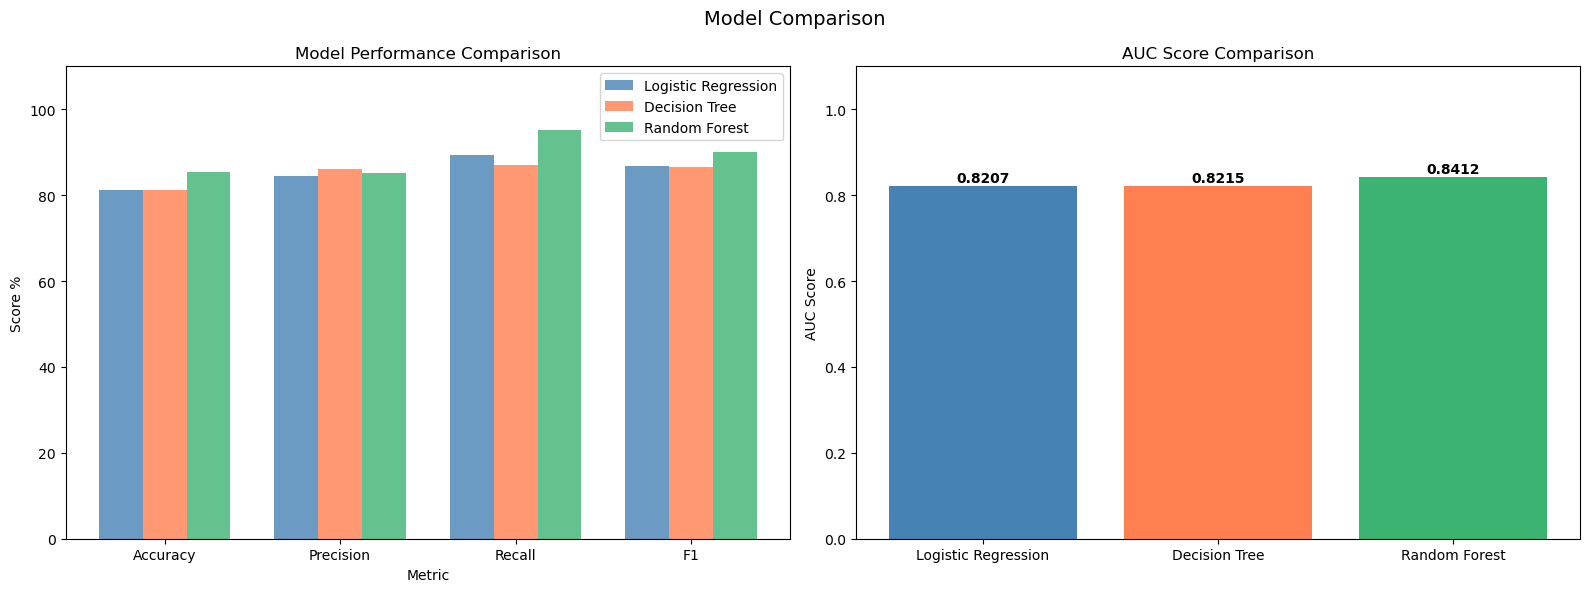

In [21]:
# Create a figure with two subplots for comparing model performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define the evaluation metrics and visualization settings
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['steelblue', 'coral', 'mediumseagreen']
x = np.arange(len(metrics))
width = 0.25

# Plot grouped bar charts to compare performance metrics across models
for i, (name, color) in enumerate(zip(results.keys(), colors)):
    values = [results[name][m] for m in metrics]
    axes[0].bar(x + i*width, values, width, label=name, color=color, alpha=0.8)
    
    # Customize the performance comparison chart
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Score %')
    axes[0].set_title('Model Performance Comparison')
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(metrics)
    axes[0].legend()
    axes[0].set_ylim(0, 110)

# Extract AUC scores for each model
model_names = list(results.keys())
auc_scores = [results[m]['AUC'] for m in model_names]

# Plot a bar chart comparing the AUC scores
bars = axes[1].bar(model_names, auc_scores, color=colors)
axes[1].set_title('AUC Score Comparison')
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim(0, 1.1)

# Display the AUC value above each bar
for bar, score in zip(bars, auc_scores): 
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01, f'{score:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### ROC Curve Comparison

The ROC curve compares the classification performance of each model across different decision thresholds.

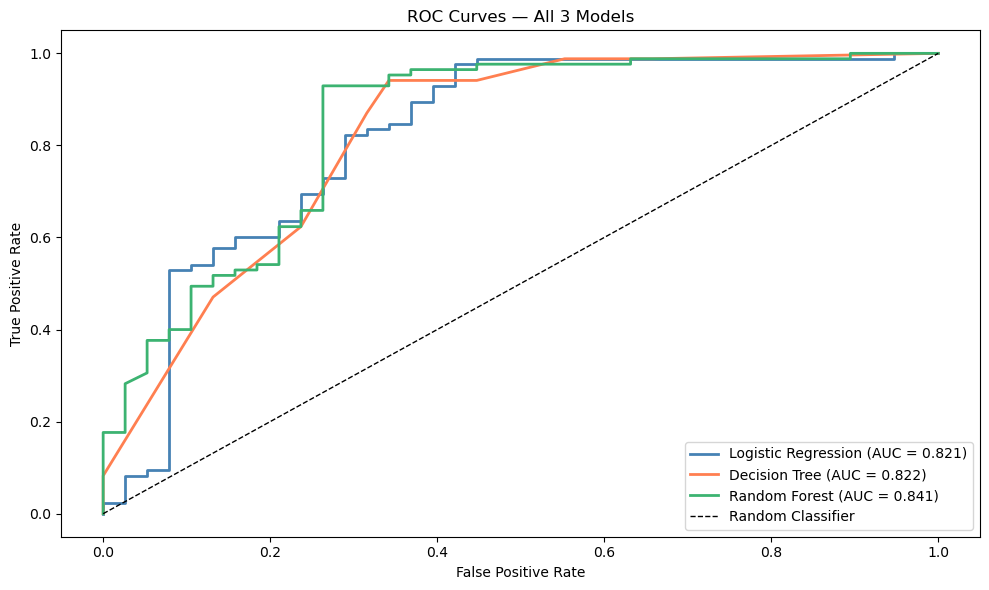

In [22]:

plt.figure(figsize=(10, 6))

# Compute and plot the ROC curve for each model
for (name, (model, X_eval)), color in zip(models.items(), colors):
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test,y_proba)
    auc_val = auc(fpr,tpr)
    plt.plot(fpr,tpr,color = color, linewidth = 2, label = f"{name} (AUC = {auc_val:.3f})")

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.title('ROC Curves — All 3 Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Model Selection

In [23]:
# Identify the best-performing model based on the highest ROC AUC score
best_name = max(results, key=lambda x: results[x]['AUC'])
print(f"\nBest model: {best_name}")
print(f"AUC: {results[best_name]['AUC']}")

# Select the corresponding model, evaluation dataset, and preprocessing requirements
if best_name == 'Logistic Regression':
    best_model  = lr_model
    best_X_test = X_test_scaled_df
    uses_scaler = True
elif best_name == 'Random Forest':
    best_model  = rf_model
    best_X_test = X_test
    uses_scaler = False
else:
    best_model  = dt_model
    best_X_test = X_test
    uses_scaler = False

print(f"\nSelected: {best_name}")
print(f"Uses scaler: {uses_scaler}")

# Store model metadata required for deployment and inference
model_info = {
    'best_model_name': best_name,
    'uses_scaler':     uses_scaler,
    'feature_cols':    feature_cols
}
print(f"\nModel info: {model_info}")


Best model: Random Forest
AUC: 0.8412

Selected: Random Forest
Uses scaler: False

Model info: {'best_model_name': 'Random Forest', 'uses_scaler': False, 'feature_cols': ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'EMI', 'Balance_Income', 'LoanAmount_log', 'Total_Income_log']}


## 12.Feature Importance

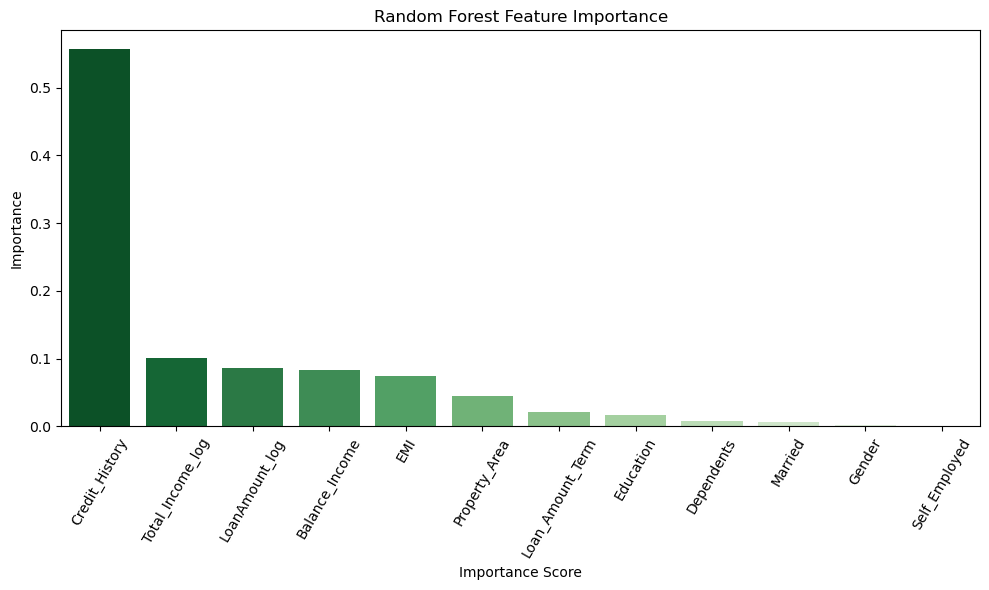


Top 5 most important features:
             Feature  Importance
6     Credit_History    0.557043
11  Total_Income_log    0.101390
10    LoanAmount_log    0.085814
9     Balance_Income    0.083461
8                EMI    0.073918


In [24]:
# Calculate and rank feature importance scores from the Random Forest model

rf_importance = pd.DataFrame({'Feature' : feature_cols,
                             'Importance' : rf_model.feature_importances_}).sort_values(by = 'Importance', ascending = False)

# Visualize the relative importance of each feature
plt.figure(figsize = (10, 6))
sns.barplot(data = rf_importance, x = 'Feature', y = 'Importance', palette = 'Greens_r')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tick_params(axis = 'x', rotation = 60)
plt.tight_layout()
plt.show()

# Display the five most influential features
print("\nTop 5 most important features:")
print(rf_importance.head())

## 13. Save Model

In [28]:
# Create the directory for storing model artifacts
os.makedirs('../models', exist_ok=True)

# Save best model
joblib.dump(best_model, '../models/loan_model.pkl')
print("Model saved!")

# Save feature names
joblib.dump(feature_cols, '../models/feature_names.pkl')
print("Feature names saved!")

# Save model metadata required for deployment and inference
#lambda uses this to check whether the sclaer is needed
import json
metadata = {
    'model_type':       best_name,
    'uses_scaler':      uses_scaler,
    'features':         feature_cols,
    'auc_score':        results[best_name]['AUC'],
    'accuracy':         results[best_name]['Accuracy'],
    'f1_score':         results[best_name]['F1'],
    'training_samples': len(X_train),
    'approved_label':   1,
    'rejected_label':   0
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved!")

# Verify that all model artifacts were saved successfully
print("\nSaved files:")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}')
    print(f"  {f:35s} {size/1024:.1f} KB")

Model saved!
Feature names saved!
Metadata saved!

Saved files:
  feature_names.pkl                   0.2 KB
  loan_model.pkl                      150.6 KB
  model_metadata.json                 0.5 KB


## 14. Verification

In [29]:
# Load everything fresh
test_model    = joblib.load('../models/loan_model.pkl')
test_features = joblib.load('../models/feature_names.pkl')

with open('../models/model_metadata.json') as f:
    meta = json.load(f)

print(f"Model loaded: {meta['model_type']}")
print(f"Features: {test_features}")



Model loaded: Random Forest
Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'EMI', 'Balance_Income', 'LoanAmount_log', 'Total_Income_log']


In [30]:
# Married graduate, good credit, stable income
# Strong loan applicant profile

strong_case = pd.DataFrame([{
    'Gender':           1,      # Male
    'Married':          1,      # Married
    'Dependents':       0,      # No dependents
    'Education':        0,      # Graduate
    'Self_Employed':    0,      # Salaried employee
    'Loan_Amount_Term': 360.0,  # 30 year term
    'Credit_History':   1.0,    # Good credit
    'Property_Area':    2,      # Urban
    'LoanAmount_log':   np.log(120 + 1),
    'Total_Income_log': np.log(6000 + 2000 + 1),
    'EMI':              120 / 360,
    'Balance_Income':   8000 - (120/360 * 1000)
}])[feature_cols]

prob     = test_model.predict_proba(strong_case)[0][1]
decision = 'APPROVED' if prob >= 0.5 else 'REJECTED'
print(f"Strong Case")
print(f"Profile: Married graduate, good credit, income 8000, loan 120k, 30yr term")
print(f"Probability: {prob*100:.1f}%  →  {decision}")



# Single, not graduate, bad credit, high loan
# Weak loan applicant profile

rejection_case = pd.DataFrame([{
    'Gender':           0,      # Female
    'Married':          0,      # Single
    'Dependents':       3,      # 3+ dependents
    'Education':        1,      # Not graduate
    'Self_Employed':    1,      # Self employed
    'Loan_Amount_Term': 360.0,  # 30 year term
    'Credit_History':   0.0,    # Bad credit
    'Property_Area':    0,      # Rural
    'LoanAmount_log':   np.log(400 + 1),
    'Total_Income_log': np.log(2000 + 0 + 1),
    'EMI':              400 / 360,
    'Balance_Income':   2000 - (400/360 * 1000)
}])[feature_cols]

prob     = rf_model.predict_proba(rejection_case)[0][1]
decision = 'APPROVED' if prob >= 0.5 else 'REJECTED'
print(f"Rejection Case")
print(f"Profile: Single, not graduate, bad credit, income 2000, loan 400k, 30yr term")
print(f"Probability: {prob*100:.1f}%  →  {decision}")


# Graduate but self employed
# Good credit but high loan relative to income
# Could go either way

borderline_case = pd.DataFrame([{
    'Gender':           1,      # Male
    'Married':          1,      # Married
    'Dependents':       2,      # 2 dependents
    'Education':        0,      # Graduate
    'Self_Employed':    1,      # Self employed (risky)
    'Loan_Amount_Term': 180.0,  # 15 year term (shorter)
    'Credit_History':   1.0,    # Good credit
    'Property_Area':    1,      # Semi-urban
    'LoanAmount_log':   np.log(200 + 1),
    'Total_Income_log': np.log(4000 + 1500 + 1),
    'EMI':              200 / 180,
    'Balance_Income':   5500 - (200/180 * 1000)
}])[feature_cols]

prob     = rf_model.predict_proba(borderline_case)[0][1]
decision = 'APPROVED' if prob >= 0.5 else 'REJECTED'
print(f"Borderline Case")
print(f"Profile: Married graduate, self employed, good credit, income 5500, loan 200k, 15yr term")
print(f"Probability: {prob*100:.1f}%  →  {decision}")

Strong Case
Profile: Married graduate, good credit, income 8000, loan 120k, 30yr term
Probability: 61.3%  →  APPROVED
Rejection Case
Profile: Single, not graduate, bad credit, income 2000, loan 400k, 30yr term
Probability: 30.6%  →  REJECTED
Borderline Case
Profile: Married graduate, self employed, good credit, income 5500, loan 200k, 15yr term
Probability: 53.5%  →  APPROVED


## 15. Upload to AWS S3

In [31]:
import boto3
import os

s3     = boto3.client('s3', region_name='ap-south-1')
BUCKET = 'data-lake-226'

model_files = [
    '../models/loan_model.pkl',
    '../models/feature_names.pkl',
    '../models/model_metadata.json'
]

for file in model_files:
    filename = os.path.basename(file)
    key      = f'models/loan-approval/{filename}'
    s3.upload_file(file, BUCKET, key)
    print(f"File uploaded successfully to {key}")

print("\nAll model files in S3:")
response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix='models/loan-approval/'
)
for obj in response['Contents']:
    print(f"  {obj['Key']} — {obj['Size']/1024:.1f} KB")

File uploaded successfully to models/loan-approval/loan_model.pkl
File uploaded successfully to models/loan-approval/feature_names.pkl
File uploaded successfully to models/loan-approval/model_metadata.json

All model files in S3:
  models/loan-approval/feature_names.pkl — 0.2 KB
  models/loan-approval/loan_model.pkl — 150.6 KB
  models/loan-approval/model_metadata.json — 0.5 KB


# Final Results

Best Model:
Random Forest

Performance

Accuracy: 85.37%

Precision: 85.26%

Recall: 95.29%

F1 Score: 90.00%

ROC AUC: 0.84

The trained model, preprocessing objects, and feature list were exported using Joblib and uploaded to Amazon S3 for deployment.